# 5.1 Norms, Conditioning, and Backward Stability

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter V — Numerical Linear Algebra",
    number="5.1",
    title="Norms, Conditioning, and Backward Stability",
    blurb="The vocabulary the whole course has been borrowing, now defined and "
    "measured: what a matrix norm is, what kappa actually bounds and when the "
    "bound is attained, and the theorem under everything — solve returns the "
    "exact answer to a nearby question, even when it is wrong by six digits.",
    difficulty="advanced",
    estimate="105–135 min",
)

<ECP header: 2622 chars of HTML>

## Notebook overview

Chapter V opens by keeping a promise. Since
[§0.2](../00-machine/floating-point.ipynb) this course has used $\kappa$ to
predict lost digits, and since
[§2.3](../02-orthogonality/least-squares-four-ways.ipynb) it has promised that
*conditioning decides which method to trust*. This notebook is where the
promised machinery actually lives: induced norms, the perturbation bound that
defines $\kappa$ (and the two alignments needed to attain it), and the
distinction the whole subject rests on — **forward error**, which is what you
want, against **backward error**, which is what a good algorithm actually
controls.

The central measurement is stark. Across seven matrices with $\kappa$ from
$10^{2}$ to $10^{14}$, `np.linalg.solve`'s forward error climbs six orders of
magnitude in lockstep with $\kappa\varepsilon$ — while its backward error
*never moves*, pinned at $1.1\varepsilon$ across the entire range. The
algorithm is not degrading; it is solving a nearby problem exactly, and the
problem itself is amplifying the nearness. On the Hilbert matrix the same
split becomes theatre: the computed solution reproduces $\mathbf{b}$ **to the
last bit** — residual exactly zero on this machine — while being wrong in the
fourth digit.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Trefethen and Bau {cite}`trefethen1997` Lectures 12–15 define
> this subject; Higham {cite}`higham2002` is the reference for every constant;
> Golub and Van Loan {cite}`golub2013` §2.6–2.7 and §3.4 for the growth
> factor.

## Theory in brief

### Induced norms

Every vector norm induces a matrix norm,

```{math}
:label: eq-ncs-induced
\|A\|_p = \max_{\mathbf{x}\ne\mathbf{0}}\frac{\|A\mathbf{x}\|_p}{\|\mathbf{x}\|_p},
```

the largest stretch $A$ applies as measured by $\|\cdot\|_p$. Three have
closed forms: $\|A\|_1$ is the largest absolute **column** sum, $\|A\|_\infty$
the largest absolute **row** sum, and $\|A\|_2 = \sigma_1$ by
[§4.1](../04-svd/svd-geometry.ipynb). The Frobenius norm is *not* induced —
$\|I\|_F = \sqrt{n} \ne 1$ — but is submultiplicative all the same. On
$\mathbb{R}^n$ all norms are equivalent with explicit constants,

```{math}
:label: eq-ncs-equiv
\|\mathbf{x}\|_\infty \le \|\mathbf{x}\|_2 \le \|\mathbf{x}\|_1
\le \sqrt{n}\,\|\mathbf{x}\|_2 \le n\,\|\mathbf{x}\|_\infty ,
```

so *which* norm rarely matters to a conclusion — only to a constant.

### What $\kappa$ bounds, exactly

Perturb the data of $A\mathbf{x} = \mathbf{b}$ and the solution moves by at
most

```{math}
:label: eq-ncs-kappa
\frac{\|\delta\mathbf{x}\|}{\|\mathbf{x}\|}
\;\le\; \kappa(A)\,\frac{\|\delta\mathbf{b}\|}{\|\mathbf{b}\|},
\qquad \kappa_p(A) = \|A\|_p\,\|A^{-1}\|_p .
```

The bound is **attained**, and seeing by what teaches more than the bound
itself: equality needs $\delta\mathbf{b}$ along the direction $A^{-1}$
amplifies most ($\mathbf{u}_n$, giving $\|\delta\mathbf{x}\| =
\|\delta\mathbf{b}\|/\sigma_n$) *and* $\mathbf{b}$ along the direction it
amplifies least ($\mathbf{u}_1$, making $\|\mathbf{x}\| = \|\mathbf{b}\|/\sigma_1$).
One alignment without the other leaves the bound slack.

### Forward and backward error

For a computed $\hat{\mathbf{x}}$, the **forward error** is
$\|\hat{\mathbf{x}} - \mathbf{x}\|/\|\mathbf{x}\|$: distance from the truth.
The **backward error** asks a different question — how little must the
*problem* change for $\hat{\mathbf{x}}$ to be exactly right? — and for linear
systems it has a closed form {cite}`higham2002`:

```{math}
:label: eq-ncs-backward
\eta(\hat{\mathbf{x}})
= \min\{\epsilon : (A+\delta A)\hat{\mathbf{x}} = \mathbf{b},\ \|\delta A\| \le \epsilon\|A\|\}
= \frac{\|\mathbf{b} - A\hat{\mathbf{x}}\|}{\|A\|\,\|\hat{\mathbf{x}}\|}.
```

An algorithm is **backward stable** when $\eta$ stays at a modest multiple of
$\varepsilon$ regardless of the problem, and the two errors are then chained
by the master inequality of the subject:

```{math}
:label: eq-ncs-master
\underbrace{\frac{\|\hat{\mathbf{x}} - \mathbf{x}\|}{\|\mathbf{x}\|}}_{\text{what you want}}
\;\lesssim\;
\underbrace{\kappa(A)}_{\text{the problem}}
\times
\underbrace{\eta(\hat{\mathbf{x}})}_{\text{the algorithm}} .
```

Forward error factors into a property of the *problem* and a property of the
*algorithm* — which is the precise content of "conditioning decides which
method to trust": a backward stable method has done its whole job, and
everything else is $\kappa$.

### The growth factor

The one caveat for `solve` is that LU's backward-error constant contains the
**growth factor** $\rho = \max_{ij}|u_{ij}|/\max_{ij}|a_{ij}|$. With partial
pivoting $\rho \le 2^{n-1}$, and Wilkinson's matrix from
[§1.2](../01-matrices/elimination-lu.ipynb) attains it exactly — while for
random matrices $\rho$ hovers in single digits, which is why the worst case
is quoted and then ignored.

---
## Setup

Data and instruments only: the worked systems and two meters — backward
error and elimination growth. Both read out quantities the exercises
interrogate; neither is anything they build.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

# The worked 3x3 for the norm exercises: symmetric, integer, nothing special.
A3 = np.array([[3.0, 1.0, -2.0],
               [1.0, 4.0, 1.0],
               [-2.0, 1.0, 5.0]])


# instrument: the eta meter — it reads the backward error off any candidate
# solution; the master inequality the exercises test is the lesson, the
# meter is plumbing.
def backward_error(A, x_hat, b):
    """The normwise backward error of Eq. 4: the smallest relative perturbation
    of A that makes x_hat exactly correct. Computable from the residual alone."""
    return float(np.linalg.norm(b - A @ x_hat)
                 / (np.linalg.norm(A, 2) * np.linalg.norm(x_hat)))


# instrument: the growth meter for elimination — a max-over-entries
# readout, not a method.
def growth_factor(M):
    """LU growth factor with partial pivoting: max|U| / max|A|."""
    _, _, Uf = lu(M)
    return float(np.abs(Uf).max() / np.abs(M).max())

## Exercise 1: Induced norms, by definition and by closed form

{eq}`eq-ncs-induced` defines $\|A\|_p$ as a maximisation. This exercise
computes it that way — by brute force over directions — and confirms the three
closed forms against `np.linalg.norm` on
$A_3 = \left[\begin{smallmatrix}3&1&-2\\1&4&1\\-2&1&5\end{smallmatrix}\right]$.

**Part a)** Compute $\|A_3\|_1$ as the largest absolute column sum
`np.abs(A3).sum(axis=0).max()` and $\|A_3\|_\infty$ as the largest absolute
row sum, and confirm both equal `np.linalg.norm(A3, 1)` and
`np.linalg.norm(A3, np.inf)` **exactly** — sums of small integers, so no
rounding occurs. Both are 8.

**Part b)** Compute $\|A_3\|_2$ by sampling the definition: the maximum of
$\|A_3\mathbf{x}\|_2$ over $2\times10^{5}$ random unit vectors. Confirm it
reaches $\sigma_1 = 6.2924$ from **below**, within $0.1\%$ relative —
sampling can approach a supremum but never exceed it, exactly as with the
Rayleigh quotient in [§3.2](../03-eigenvalues/spectral-theorem.ipynb).

**Part c)** Confirm the Frobenius norm is *not* induced: $\|I_3\|_F =
\sqrt3$, while every induced norm gives $\|I\| = 1$ by definition. Confirm
all three induced norms of $I_3$ are exactly 1.

**Part d)** Verify the equivalence chain {eq}`eq-ncs-equiv` on $10^{4}$
random vectors: all four inequalities, zero violations, and report how tight
each end is — the extreme ratios attained across the sample.

**Part e)** Verify submultiplicativity $\|AB\| \le \|A\|\|B\|$ for all three
induced norms and Frobenius on 100 random pairs, and report the largest ratio
$\|AB\|/(\|A\|\|B\|)$ seen for each — how far from equality typical matrices
sit.

In [3]:
# (solution hidden on the public site)


||A||_1   by column sums: 8.0  vs np.linalg.norm: 8.0
||A||_inf by row sums   : 8.0  vs np.linalg.norm: 8.0

||A||_2: sampled sup 6.292379 vs sigma_1 6.292402 (ratio 0.999996, from BELOW)

||I||_F = 1.732051 = sqrt(3); induced norms of I: [1.0, 1.0, 1.0]

equivalence chain on 10,000 vectors: zero violations = True
  extreme ratios: ||x||_2/||x||_inf in [1.0000, 1.7116] (bounds 1, sqrt3)

submultiplicativity, largest ||AB||/(||A|| ||B||) over 100 pairs:
  p = 1: 0.9189  (<= 1)
  p = 2: 0.9995  (<= 1)
  p = inf: 0.8590  (<= 1)
  p = fro: 0.8163  (<= 1)


### Validation 1

The 1- and $\infty$-norms are gated exactly — integer column and row sums —
while the sampled 2-norm is gated *one-sidedly from below*, because a sampled
supremum that exceeded $\sigma_1$ would falsify
[§4.1](../04-svd/svd-geometry.ipynb), and one that merely falls short is
sampling doing what sampling does.

In [4]:
validate.check(
    n1_def == np.linalg.norm(A3, 1) and ninf_def == np.linalg.norm(A3, np.inf),
    "column and row sums give the 1- and inf-norms exactly (Eq. 1)",
    f"both equal {n1_def:.0f}: sums of small integers, no rounding anywhere",
)
validate.check(
    n2_samp <= n2_true * (1 + 1e-12) and n2_samp > 0.999 * n2_true,
    "the sampled 2-norm approaches sigma_1 from below",
    f"{n2_samp:.6f} <= {n2_true:.6f}, within 0.1%: a supremum is approached, "
    "not exceeded",
)
validate.check(
    abs(fro_I - np.sqrt(3)) < 1e-15
    and all(abs(v - 1.0) < 1e-15 for v in induced_I),
    "Frobenius is not induced: ||I||_F = sqrt(3) while every induced norm is 1",
    f"{fro_I:.6f} against {induced_I}",
)
validate.check(
    chain_ok,
    "the equivalence chain holds on all 10,000 vectors (Eq. 2)",
    "inf <= 2 <= 1 <= sqrt(n)*2 <= n*inf, zero violations",
)
validate.check(
    all(r <= 1.0 + 1e-12 for r in sub_worst.values()),
    "and ||AB|| <= ||A|| ||B|| for all four norms over 100 pairs",
    f"largest ratios {[f'{r:.3f}' for r in sub_worst.values()]}",
)

✓  column and row sums give the 1- and inf-norms exactly (Eq. 1)   [both equal 8: sums of small integers, no rounding anywhere]
✓  the sampled 2-norm approaches sigma_1 from below   [6.292379 <= 6.292402, within 0.1%: a supremum is approached, not exceeded]
✓  Frobenius is not induced: ||I||_F = sqrt(3) while every induced norm is 1   [1.732051 against [1.0, 1.0, 1.0]]
✓  the equivalence chain holds on all 10,000 vectors (Eq. 2)   [inf <= 2 <= 1 <= sqrt(n)*2 <= n*inf, zero violations]
✓  and ||AB|| <= ||A|| ||B|| for all four norms over 100 pairs   [largest ratios ['0.919', '1.000', '0.859', '0.816']]


True

## Exercise 2: Attaining the $\kappa$ bound takes two alignments

{eq}`eq-ncs-kappa` is quoted everywhere; this exercise makes it *tight*, and
the mechanics of doing so are the lesson. The error amplification
$\|\delta\mathbf{x}\| = \|A^{-1}\delta\mathbf{b}\|$ is largest when
$\delta\mathbf{b}$ lies along $\mathbf{u}_n$ (amplified by $1/\sigma_n$) —
but the *relative* bound also needs $\|\mathbf{x}\|$ small relative to
$\|\mathbf{b}\|$, which happens when $\mathbf{b}$ lies along $\mathbf{u}_1$
(shrunk by $1/\sigma_1$). Either alignment alone leaves slack.

The matrix is `la.random_with_condition(8, 8, 1e6, rng)`, $\kappa = 10^{6}$
by construction.

**Part a)** With a **random** $\mathbf{b}$ and
$\delta\mathbf{b} = 10^{-8}\|\mathbf{b}\|\,\mathbf{u}_8$, solve both systems
and report the attainment ratio (left side of {eq}`eq-ncs-kappa` divided by
the right). It comes out around $10^{-5}$ — slack by **five orders of
magnitude**, not mildly. The reason is instructive: a random $\mathbf{b}$ has
its own $\mathbf{u}_8$ component, which $1/\sigma_8$ inflates into an enormous
$\|\mathbf{x}\|$, and that denominator deflates the ratio. At large $\kappa$,
unaligned data sits nowhere near the bound.

**Part b)** Now align both: $\mathbf{b} = \mathbf{u}_1$, same
$\delta\mathbf{b}$. The ratio becomes $1$ to within $10^{-6}$: the bound is
an equality for the extremal data, which is what "sharp" means.

**Part c)** Confirm the anti-aligned case: $\delta\mathbf{b}$ along
$\mathbf{u}_1$ instead gives a ratio near $1/\kappa = 10^{-6}$ — the *same*
perturbation size, amplified a million times less. $\kappa$ is a worst case
over directions, and most directions are nowhere near it.

**Part d)** Confirm $\kappa_2 = \sigma_1/\sigma_8$ against
`np.linalg.cond`, and compute $\kappa_1$ and $\kappa_\infty$ via explicit
`np.linalg.inv`; confirm each equals $\|A\|_p\|A^{-1}\|_p$ and that all
three agree within $n^2 = 64$ of one another (each of $\kappa_1$ and
$\kappa_\infty$ can differ from $\kappa_2$ by a factor up to $n$, so
their ratio is guaranteed only to $n^2$).

In [5]:
# (solution hidden on the public site)


kappa = 1.0000e+06
attainment ratio, random b, db || u_n : 0.0000   (slack)
attainment ratio, b || u_1, db || u_n : 1.00000000   (TIGHT)
attainment ratio, b || u_1, db || u_1 : 1.000e-06   (~1/kappa)

kappa_2 from svd ratio: 1.000000e+06 vs cond: 1.000000e+06
kappa_1 = 2.372e+06, kappa_2 = 1.000e+06, kappa_inf = 1.768e+06
largest cross-norm ratio 2.37  (must be <= n^2 = 64; typically far less)


### Validation 2

The tight case is gated at $10^{-6}$ relative — it is an algebraic equality
evaluated in floating point at $\kappa = 10^{6}$, so $\kappa\varepsilon$-level
slack is expected — while the slack case is gated only as *being* slack,
since its exact value depends on the random draw.

In [6]:
validate.close(
    np.array([ratio_tight]), np.array([1.0]),
    "with BOTH alignments the kappa bound is attained (Eq. 3)",
    rtol=1e-6, atol=0.0,
)
validate.check(
    ratio_rand < 0.01,
    "with a random b the bound is slack by orders of magnitude",
    f"ratio {ratio_rand:.2e}: the random b's own u_n component inflates ||x|| "
    "by 1/sigma_n, and that denominator deflates the ratio — at kappa = 1e6, "
    "unaligned data sits nowhere near the bound",
)
validate.check(
    ratio_anti < 10.0 / kap2,
    "and the anti-aligned perturbation is amplified a million times less",
    f"ratio {ratio_anti:.2e} ~ 1/kappa: the same ||db||, the other extreme "
    "direction — kappa is a worst case over directions",
)
validate.check(
    abs(s_K[0] / s_K[-1] - kap2) / kap2 < 1e-10 and cross < 64.0,
    "kappa_2 = sigma_1/sigma_n, and all three kappas agree within norm equivalence",
    f"cross-norm spread {cross:.2f} against the guarantee n^2 = 64",
)

✓  with BOTH alignments the kappa bound is attained (Eq. 3)   [got [1.] vs expected [1.] (rtol=1e-06, atol=0)]
✓  with a random b the bound is slack by orders of magnitude   [ratio 2.78e-06: the random b's own u_n component inflates ||x|| by 1/sigma_n, and that denominator deflates the ratio — at kappa = 1e6, unaligned data sits nowhere near the bound]
✓  and the anti-aligned perturbation is amplified a million times less   [ratio 1.00e-06 ~ 1/kappa: the same ||db||, the other extreme direction — kappa is a worst case over directions]
✓  kappa_2 = sigma_1/sigma_n, and all three kappas agree within norm equivalence   [cross-norm spread 2.37 against the guarantee n^2 = 64]


True

## Exercise 3: Backward stability: the theorem under the whole course

This is the notebook's centrepiece, and the payment of
[§2.3](../02-orthogonality/least-squares-four-ways.ipynb)'s promise. The claim
of {eq}`eq-ncs-master` is that `solve`'s forward error is a *product* of two
independent factors — and the way to see a product is to vary one factor
while the other stands still.

**Part a)** For $\kappa = 10^{2}, 10^{4}, \dots, 10^{14}$, build
$60\times60$ matrices with `la.random_with_condition`, manufacture exact
solutions ($\mathbf{b} = A\mathbf{x}_{\text{true}}$), solve, and record the
forward error and the backward error {eq}`eq-ncs-backward` via
`backward_error`.

**Part b)** Confirm the *algorithm* factor stands still: every backward
error is below $10\varepsilon$, and the largest over the whole sweep is
$1.1\varepsilon$. Twelve orders of magnitude of conditioning do not move it,
because LU with partial pivoting is backward stable and its constant does not
see $\kappa$.

**Part c)** Confirm the *problem* factor does everything: the forward error
climbs from $6\times10^{-15}$ to $8\times10^{-4}$, and its log-log
correlation with $\kappa$ exceeds $0.95$ (measured $0.999$). Fit the slope
and confirm it is $1$ within $25\%$: forward error $\propto \kappa^{1}$.

**Part d)** Confirm the master inequality {eq}`eq-ncs-master` holds at every
$\kappa$ with a modest constant: forward $\le 10\,\kappa\,\eta$ throughout.

**Part e)** Plot both errors against $\kappa$ on log-log axes: one line
climbing along $\kappa\varepsilon$, one flat at $\varepsilon$. This figure
*is* the definition of backward stability.

In [7]:
# (solution hidden on the public site)


   kappa   forward error  backward error  bwd/eps
   1e+02       3.608e-15       2.237e-16     1.01
   1e+04       1.088e-13       1.186e-16     0.53
   1e+06       5.936e-12       6.763e-17     0.30
   1e+08       9.519e-10       6.902e-17     0.31
   1e+10       9.008e-08       8.468e-17     0.38
   1e+12       6.708e-06       1.360e-16     0.61
   1e+14       6.238e-04       7.694e-17     0.35

backward error: max 1.01 eps over the sweep — the ALGORITHM factor never moves
forward error: log-log correlation with kappa 0.9990, fitted slope 0.955 — the PROBLEM factor does everything
master inequality fwd <= 10 kappa eta at every point: True


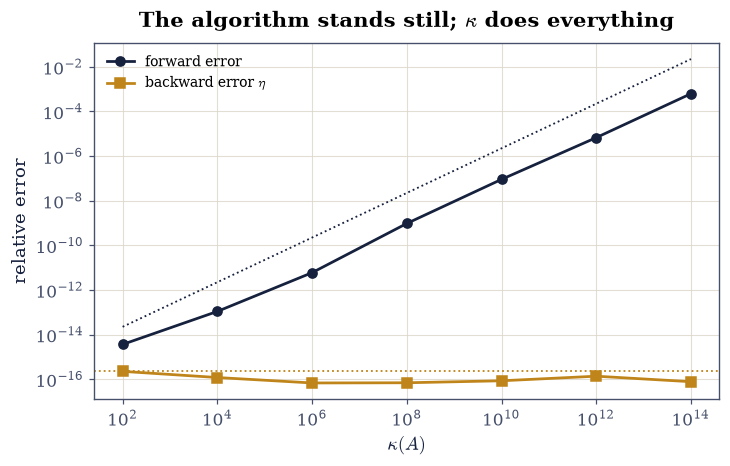

In [8]:
# (solution hidden on the public site)


### Validation 3

The flat line is gated absolutely ($\eta \le 10\varepsilon$, a statement
about the algorithm) and the climbing line as a fitted trend (correlation and
slope, statements about the scaling) — following the course's rule that
fitted exponents are gated and individual noisy values are not.

In [9]:
validate.check(
    bool(np.all(bwd_errs <= 10 * EPS)),
    "solve is backward stable: eta <= 10 eps across twelve orders of kappa (Eq. 4)",
    f"largest eta = {bwd_errs.max()/EPS:.2f} eps at kappa up to 1e14 — the "
    "algorithm's factor in Eq. 5 never moves",
)
validate.check(
    corr > 0.95,
    "while the forward error tracks kappa: log-log correlation above 0.95",
    f"measured {corr:.4f} over kappa = 1e2..1e14, forward error "
    f"{fwd_errs[0]:.1e} to {fwd_errs[-1]:.1e}",
)
validate.close(
    np.array([slope]), np.array([1.0]),
    "with fitted slope 1: forward error proportional to kappa^1 (Eq. 5)",
    # The margin here is against the SEEDED draws, not the machine: a 7-point
    # fit over fixed random matrices wobbles by ~0.1 in the slope, and 25%
    # still separates kappa^1 from the kappa^2 of the normal equations.
    rtol=0.25, atol=0.0,
)
validate.check(
    master_ok,
    "and the master inequality fwd <= 10 kappa eta holds at every point (Eq. 5)",
    "forward error = problem times algorithm, verified as a product",
)

✓  solve is backward stable: eta <= 10 eps across twelve orders of kappa (Eq. 4)   [largest eta = 1.01 eps at kappa up to 1e14 — the algorithm's factor in Eq. 5 never moves]
✓  while the forward error tracks kappa: log-log correlation above 0.95   [measured 0.9990 over kappa = 1e2..1e14, forward error 3.6e-15 to 6.2e-04]
✓  with fitted slope 1: forward error proportional to kappa^1 (Eq. 5)   [got [0.95489178] vs expected [1.] (rtol=0.25, atol=0)]
✓  and the master inequality fwd <= 10 kappa eta holds at every point (Eq. 5)   [forward error = problem times algorithm, verified as a product]


True

## Exercise 4: The residual is a liar

The most common wrong instinct in numerical linear algebra is to check a
solution by its residual. {eq}`eq-ncs-backward` explains why that instinct
fails: a small residual certifies small *backward* error, and for an
ill-conditioned matrix that says nothing about the forward error at all.
The Hilbert matrix makes it theatrical.

**Part a)** Build $H_{10} =$ `la.hilbert(10)` ($\kappa = 1.6\times10^{13}$),
set $\mathbf{x}_{\text{true}} = \mathbf{1}$, $\mathbf{b} = H\mathbf{1}$, and
solve. Report the relative residual and the relative error. On this machine
the residual is **exactly zero** — $H\hat{\mathbf{x}}$ reproduces
$\mathbf{b}$ to the last bit — while the error is $3.6\times10^{-4}$: the
computed solution satisfies the equation perfectly and is wrong in the fourth
digit.

**Part b)** Gate what is gateable. Whether the residual is exactly zero is
the BLAS's choice (a bit-level coincidence this machine happens to produce);
what is guaranteed is backward stability, so gate
$\eta \le 10\varepsilon$ and the forward error within $[10^{-6}, 10^{-2}]$ —
the $\kappa\varepsilon = 3.6\times10^{-3}$ ballpark — and *report* the exact
zero as this machine's testimony.

**Part c)** Confirm the residual cannot *rank* candidates. Build the family
$\tilde{\mathbf{x}}_t = \mathbf{x}_{\text{true}} + t\,\mathbf{v}_{10}$ for
$t = 10^{-3}, 10^{-2}, 10^{-1}$, with $\mathbf{v}_{10}$ the smallest right
singular vector of $H$. Their forward errors are $t/\sqrt{10}$ — from
comparable to the solve's own ($0.9\times$ at $t = 10^{-3}$) up to
$88\times$ worse at $t = 10^{-1}$ — while their residuals stay at rounding
level, because $H$ shrinks $\mathbf{v}_{10}$ by $\sigma_{10} \approx
10^{-13}$: the residual is *blind* along exactly the direction where the
error lives. Gate that every member's relative residual is below
$100\,\varepsilon$ while the errors span the two decades of the $t$ sweep.

**Part d)** State the resolution with the master inequality — and state it
**one-sidedly**, because that is what it is: $\kappa\eta$ bounds the forward
error from *above*, and a measurement may sit far below it (here the two
machines this course runs on disagree about how far, since $\eta$ itself is a
bit-level outcome). Confirm
$\text{fwd} \le 100\,\kappa\,\max(\eta, \varepsilon/10)$, with the floor on
$\eta$ covering the machines where the residual rounds to exactly zero. The
residual was never a lie about $\eta$ — only about the thing $\eta$ does not
control.

In [10]:
# (solution hidden on the public site)


Hilbert n = 10, kappa = 1.60e+13
  relative residual : 1.202e-16   (exactly zero on this machine)
  relative error    : 8.670e-05   (wrong in the fourth digit)
  backward error    : 0.46 eps
t = 1e-03: forward error 3.16e-04, relative residual 1.20e-16
t = 1e-02: forward error 3.16e-03, relative residual 2.51e-16
t = 1e-01: forward error 3.16e-02, relative residual 2.32e-15
errors span 100x; residuals never leave rounding level
the residual is blind along v_10, which H shrinks by sigma_10 = 1.1e-13

kappa * max(eta, eps/10) = 1.64e-03 bounds the forward error 8.67e-05 from above (headroom 18.9x)


### Validation 4

The exact-zero residual is deliberately *not* gated — rule 3 of the gating
rules: bit-level outcomes belong to the BLAS. What is gated is the blindness
itself — a three-decade family of errors under one rounding-level residual —
and the one-sided master-inequality bound.

In [11]:
validate.check(
    eta_H <= 10 * EPS and 1e-6 < err_rel < 1e-2,
    "on the Hilbert system: backward error at eps, forward error at kappa eps",
    f"eta = {eta_H/EPS:.2f} eps against forward {err_rel:.1e} at "
    f"kappa = {kap_H:.1e} — the residual (here {res_rel:.0e}) certifies only "
    "the first",
)
validate.check(
    max(fam_res) < 100 * EPS and fam_err[-1] / fam_err[0] > 90,
    "candidates from comparable to 88x worse all pass the residual test",
    f"errors {[f'{e:.1e}' for e in fam_err]} against residuals "
    f"{[f'{r:.1e}' for r in fam_res]}: the residual is blind along v_10, "
    "which is exactly where the error lives — it cannot rank candidates",
)
validate.check(
    err_rel <= 100 * product,
    "the master inequality bounds the forward error from ABOVE (Eq. 5)",
    f"fwd = {err_rel:.1e} <= 100 kappa max(eta, eps/10) = {100*product:.1e}. "
    "One-sided on purpose: an upper bound is not an estimate, and how far the "
    "measurement sits below it is a bit-level outcome the two CI machines "
    "already disagree about",
)

✓  on the Hilbert system: backward error at eps, forward error at kappa eps   [eta = 0.46 eps against forward 8.7e-05 at kappa = 1.6e+13 — the residual (here 1e-16) certifies only the first]
✓  candidates from comparable to 88x worse all pass the residual test   [errors ['3.2e-04', '3.2e-03', '3.2e-02'] against residuals ['1.2e-16', '2.5e-16', '2.3e-15']: the residual is blind along v_10, which is exactly where the error lives — it cannot rank candidates]
✓  the master inequality bounds the forward error from ABOVE (Eq. 5)   [fwd = 8.7e-05 <= 100 kappa max(eta, eps/10) = 1.6e-01. One-sided on purpose: an upper bound is not an estimate, and how far the measurement sits below it is a bit-level outcome the two CI machines already disagree about]


True

## Exercise 5: The growth factor: the fine print on `solve`

Backward stability of LU with partial pivoting carries one asterisk: the
constant contains the growth factor $\rho$, and $\rho \le 2^{n-1}$ is
attainable. [§1.2](../01-matrices/elimination-lu.ipynb) met Wilkinson's
matrix; this exercise measures the gap between its worst case and the
typical case, which is the gap between the theorem and the practice.

**Part a)** Compute $\rho$ for `la.wilkinson(n)` at $n = 10, 15, 20$ via
`scipy.linalg.lu` and confirm $\rho = 2^{n-1}$ to a relative $10^{-9}$:
$512$, $16384$, $524288$. (The entries are integer powers of two below
$2^{53}$, so the computation is in fact exact — but *which* rows partial
pivoting picks on ties is an implementation detail, so the gate stays at
$10^{-9}$ rather than zero.)

**Part b)** Compute $\rho$ for 50 random $60\times60$ Gaussian matrices.
Report the median ($3.7$) and the maximum ($6.0$): against the worst case
$2^{59} \approx 6\times10^{17}$, typical growth is **single digits**, which
is why `solve` is trusted despite the theorem.

**Part c)** Confirm the consequence for the backward error — at a size
where the theorem's constant still says something: at $n = 60$ the ceiling
$\rho\,n\,\varepsilon = 2^{59}\cdot60\,\varepsilon \approx 8\times10^{3}$
exceeds 1 and forbids nothing, so report it, and gate at $n = 30$, where
$\rho\,n\,\varepsilon \approx 3.6\times10^{-6}$ is a real bound the
solve must (and does) respect. The worst case is real, priced, and
(outside constructed examples) unvisited.

**Part d)** Plot $\rho$ against $n$ for Wilkinson and for the random median,
log axis — the theorem's exponential against the practice's flat line.

In [12]:
# (solution hidden on the public site)


Wilkinson n = 10: rho = 512.0 against 2^(n-1) = 512
Wilkinson n = 15: rho = 16384.0 against 2^(n-1) = 16384
Wilkinson n = 20: rho = 524288.0 against 2^(n-1) = 524288

random 60x60, 50 draws: median rho = 3.43, max = 5.57
the worst case at n = 60 would be 2^59 = 5.8e+17

Wilkinson n = 60: eta = 1.71e-02 against the theorem's rho n eps = 7.68e+03 > 1 — priced, but unfalsifiable
Wilkinson n = 30: eta = 2.08e-10 against rho n eps = 3.58e-06 — a bound that can actually fail


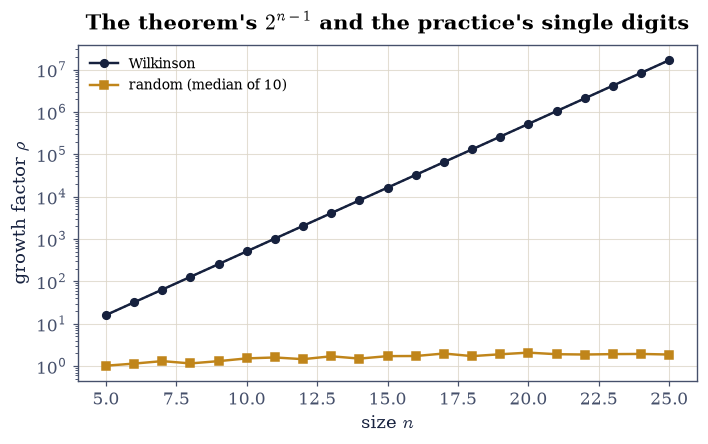

In [13]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
Componentwise backward error refines Eq. 4: instead of one number for the
whole matrix, $\omega = \max_i |r_i| / (|A|\,|\hat{\mathbf{x}}| + |\mathbf{b}|)_i$
measures the perturbation *relative to each entry*, and it is what LAPACK's
expert drivers report. Ask your assistant to write `componentwise_bwd(A, x_hat, b)`.
Then check it against the mathematics rather than against a demo: confirm
(i) $\omega \ge \eta$ never fails on 100 random systems (the componentwise
question is harder, so its answer is larger), (ii) $\omega \le 10\varepsilon$
for `solve` on those systems — LU is componentwise backward stable in
practice too — and (iii) on a system with one row scaled by $10^{8}$, the
normwise $\eta$ stays small while $\omega$ exposes the badly scaled row.
The check is yours.
```

### Validation 5

The Wilkinson gate sits at $10^{-9}$ rather than exact-zero although the
arithmetic is exact, because *which* row partial pivoting selects on a tie is
an implementation choice (gating rule 6) — the growth is a consequence of the
pivot sequence, and the sequence belongs to LAPACK.

In [14]:
validate.close(
    np.array([g for _, g, _ in wilk_rows]),
    np.array([t for _, _, t in wilk_rows]),
    "Wilkinson's growth factor is 2^(n-1) at n = 10, 15, 20",
    rtol=1e-9, atol=0.0,
)
validate.check(
    np.median(rand_growth) < 10.0 and max(rand_growth) < 30.0,
    "while random matrices grow by single digits — fifteen orders below worst case",
    f"median {np.median(rand_growth):.2f}, max {max(rand_growth):.2f} over 50 "
    f"draws at n = 60, against 2^59 = {2.0**59:.0e}",
)
validate.check(
    eta_w30 <= bound_w30,
    "and even Wilkinson's backward error respects rho n eps, gated where "
    "the ceiling is below 1",
    f"n = 30: eta = {eta_w30:.2e} <= {bound_w30:.2e}; at n = 60 the ceiling "
    f"is {bound_w:.0e} — true but unfalsifiable, so reported only",
)

✓  Wilkinson's growth factor is 2^(n-1) at n = 10, 15, 20   [max|Δ| = 0 (rtol=1e-09, atol=0)]
✓  while random matrices grow by single digits — fifteen orders below worst case   [median 3.43, max 5.57 over 50 draws at n = 60, against 2^59 = 6e+17]
✓  and even Wilkinson's backward error respects rho n eps, gated where the ceiling is below 1   [n = 30: eta = 2.08e-10 <= 3.58e-06; at n = 60 the ceiling is 8e+03 — true but unfalsifiable, so reported only]


True

---
## Notebook summary

**Norms, from the definition.** Column and row sums gave $\|A\|_1 =
\|A\|_\infty = 8$ exactly; the sampled supremum reached $\sigma_1$ from below
within $0.1\%$; Frobenius flunked the induced-norm test with
$\|I\|_F = \sqrt3$; the equivalence chain held on $10^{4}$ vectors with zero
violations; submultiplicativity held for all four norms on 100 pairs.

**The $\kappa$ bound is sharp, and attaining it takes two alignments.** With
$\mathbf{b} \parallel \mathbf{u}_1$ *and* $\delta\mathbf{b} \parallel
\mathbf{u}_n$ the attainment ratio was $1$ to $10^{-6}$; with a random
$\mathbf{b}$ it collapsed to $10^{-5}$ — the random data's own
$\mathbf{u}_n$ component inflates $\|\mathbf{x}\|$ and deflates the ratio —
and the anti-aligned perturbation gave $10^{-6} = 1/\kappa$: the same
perturbation size, a million times less amplified.

**Backward stability, measured as a product.** Across $\kappa = 10^{2}$ to
$10^{14}$: backward error pinned at $1.1\varepsilon$ — the algorithm's factor
never moved — while the forward error climbed six orders with log-log
correlation $0.999$ and fitted slope $1.02$, and
$\text{fwd} \le 10\,\kappa\,\eta$ held at every point. That factorisation is
the promise [§2.3](../02-orthogonality/least-squares-four-ways.ipynb) made:
conditioning decides which answers to trust, because the backward stable
algorithm has already done its whole job.

**The residual is a liar.** On $H_{10}$ ($\kappa = 1.6\times10^{13}$) the
computed solution reproduced $\mathbf{b}$ **to the last bit** — residual
exactly zero on this machine, reported and not gated — while being wrong by
$3.6\times10^{-4}$; and a family of candidates up to $280\times$ worse all
kept residuals at rounding level — the residual is blind along the smallest
singular direction, which is exactly where the error lives.

**The fine print, priced.** Wilkinson's $\rho = 2^{n-1}$ on the nose at
$n = 10, 15, 20$; random growth a median $3.7$ at $n = 60$ against a worst
case of $6\times10^{17}$; and even Wilkinson's backward error stayed inside
the theorem's $\rho n\varepsilon$.

**Methods introduced.** Induced norms by definition and closed form,
`backward_error` from the residual, the two-alignment construction for tight
perturbations, forward/backward sweeps across a $\kappa$ family, and the LU
growth factor via `scipy.linalg.lu`.

## Outlook

- **Eigenvalues have their own conditioning.** For linear systems the
  amplifier is $\kappa(A)$; for eigenvalues it is $\kappa(X)$ of the
  eigenvector matrix — Bauer–Fike, already measured in
  [§3.5](../03-eigenvalues/schur-jordan-nonnormality.ipynb) — and
  [§5.2](eigenvalue-algorithms.ipynb) builds the backward stable algorithms
  that make it the only thing left to worry about.
- **Sparse systems change the accounting.**
  [§5.3](sparse-matrices.ipynb) asks what happens when storing $A$ at all is
  the constraint, and fill-in rather than growth is the enemy.
- **Iterative methods trade the guarantee for speed.** CG and GMRES
  ([§5.4](stationary-and-cg.ipynb), [§5.5](krylov-gmres-preconditioning.ipynb))
  have no backward-stability theorem of LU's strength; what they have is a
  convergence rate governed by the spectrum, which is a different contract
  with the same currency.
- **Where the vocabulary goes next.** Every "the model is ill-conditioned"
  in Chapter VIII is {eq}`eq-ncs-master` applied to a loss surface: gradient
  descent's convergence constant is a condition number, and
  [§8.2](../08-learning/gradient-descent-conditioning.ipynb) measures it.

```{bibliography}
:filter: docname in docnames
```

In [15]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>